In [1]:
import cupy as cp
import math
import matplotlib.pyplot as plt
from model.network import Network

## Loading the Data

In [2]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [3]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [4]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

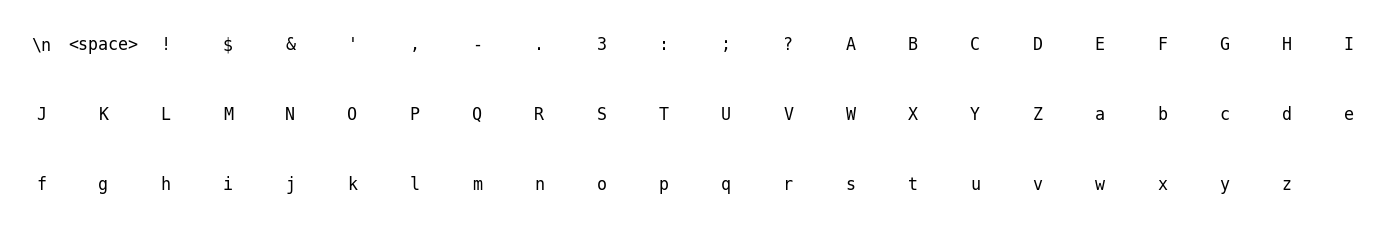

In [5]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [7]:
embedding_dim = 64
hidden_size = 512
hidden_2_size = 256

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Recurrent", "input_size": hidden_size, "num_neurons": hidden_2_size},
    {"type": "Softmax", "input_size": hidden_2_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()


Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 64)
  Parameters: 4,160

Layer 2: RecurrentLayer
  Weights Shape: (64, 512) | State Weights Shape: (512, 512) | Biases Shape: (512,)
  Parameters: 295,424

Layer 3: RecurrentLayer
  Weights Shape: (512, 256) | State Weights Shape: (256, 256) | Biases Shape: (256,)
  Parameters: 196,864

Layer 4: SoftmaxLayer
  Weights Shape: (256, 65) | Biases Shape: (65,)
  Parameters: 16,705

Total Parameters: 513,153


c:\Users\DANIELPEDERZINI\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Training the Model

In [8]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [9]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [10]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [11]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
    clip_value: float | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size, clip_value=clip_value)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [21]:
hyperparameters = {
    "sequence_length": 64,
    "batch_size": 64,
    "epochs": 500,
    "train_steps_per_epoch": x_train_indices.shape[0],
    "validation_steps": x_test_indices.shape[0],
    "base_learning_rate": 0.02,
    "min_learning_rate": 0.0002,
    "weight_decay_lambda": 5e-4,
    "momentum": 0.9,
    "early_stopping_patience": 10,
    "clip_value": 5.0,
}

print(hyperparameters)

{'sequence_length': 64, 'batch_size': 64, 'epochs': 500, 'train_steps_per_epoch': 880791, 'validation_steps': 234596, 'base_learning_rate': 0.02, 'min_learning_rate': 0.0002, 'weight_decay_lambda': 0.0005, 'momentum': 0.9, 'early_stopping_patience': 10, 'clip_value': 5.0}


In [13]:
epoch_summaries = []

total_steps = hyperparameters["epochs"] * hyperparameters["train_steps_per_epoch"]
global_step = 0

best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

for epoch in range(1, hyperparameters["epochs"] + 1):
    learning_rate = hyperparameters["min_learning_rate"] + 0.5 * (hyperparameters["base_learning_rate"] - hyperparameters["min_learning_rate"]) * (1 + math.cos(math.pi * global_step / total_steps))

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_train_indices,
        y_indices=y_train_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        learning_rate=learning_rate,
        max_steps=hyperparameters["train_steps_per_epoch"],
        weight_decay_lambda=hyperparameters["weight_decay_lambda"],
        momentum=hyperparameters["momentum"],
        clip_value=hyperparameters["clip_value"],
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        max_steps=hyperparameters["validation_steps"],
    )

    epoch_summary = {
        "epoch": epoch,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += hyperparameters["train_steps_per_epoch"]

    if epochs_without_improvement >= hyperparameters["early_stopping_patience"]:
        print(f"Early stopping triggered after {epoch} epochs due to no improvement.")
        break

{'epoch': 1, 'learning_rate': 0.02, 'train_perplexity': 10.099017410397831, 'test_perplexity': 7.636460589460199}
{'epoch': 2, 'learning_rate': 0.019999804582475758, 'train_perplexity': 6.9220241427051725, 'test_perplexity': 6.586528948543345}
{'epoch': 3, 'learning_rate': 0.01999921833761778, 'train_perplexity': 6.191220104045233, 'test_perplexity': 6.08005295513555}
{'epoch': 4, 'learning_rate': 0.019998241288570008, 'train_perplexity': 5.778385959258472, 'test_perplexity': 5.75772559203036}
{'epoch': 5, 'learning_rate': 0.01999687347390467, 'train_perplexity': 5.498802967655203, 'test_perplexity': 5.526574433390172}
{'epoch': 6, 'learning_rate': 0.019995114947620744, 'train_perplexity': 5.292601989813359, 'test_perplexity': 5.3522683416734305}
{'epoch': 7, 'learning_rate': 0.019992965779141832, 'train_perplexity': 5.132692588500486, 'test_perplexity': 5.21703538316847}
{'epoch': 8, 'learning_rate': 0.019990426053313436, 'train_perplexity': 5.004387950746164, 'test_perplexity': 5.109

In [14]:
print(f"Best validation perplexity: {best_perplexity:.4f} at epoch {epoch - hyperparameters['early_stopping_patience']}")

Best validation perplexity: 4.1247 at epoch 128


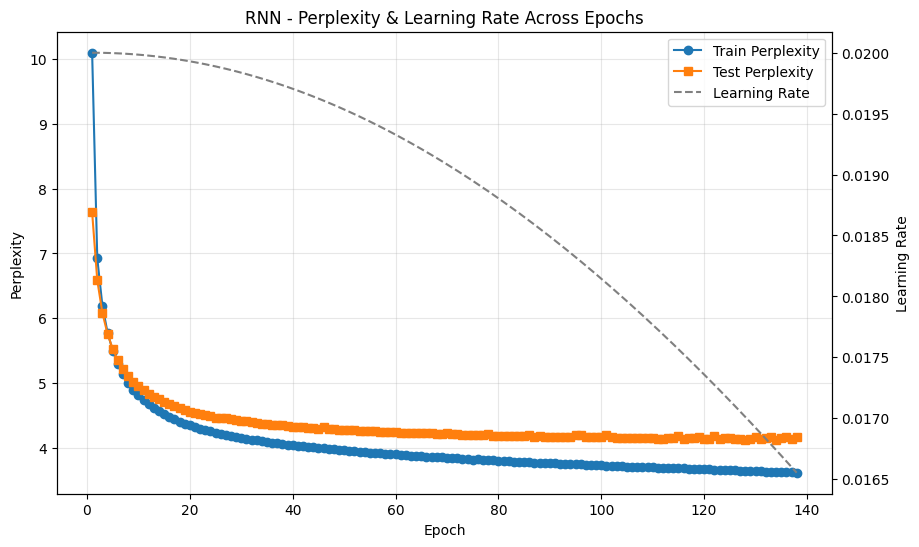

In [15]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
learning_rates = [summary["learning_rate"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, learning_rates, color="gray", linestyle="--", linewidth=1.5, label="Learning Rate")
ax2.set_ylabel("Learning Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("RNN - Perplexity & Learning Rate Across Epochs")
plt.show()

In [16]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [25]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.85, print_during=True)

DANIELA:
Well, I know, good sir, he knew him goes to slain, for what's one to the day! and, have done best, and flouting
Lord our flousince honour for itself.

VOLUMNIA:
Is the little friends in a language
Please my fair, to feal to hear it
A natures came for these tratest of act an shed and honours ere to the reautors of the fire?

SICIUS:
Walked the way, parted fathers dishing away his signable to a word,
If touchsers caured of drable painting. Laotless terrers and water for provorture not for a strength not to hang him with not litter world but not
known ignorant of my foreaties bloods, but they to beseech your lords!

CORIOLANUS:
Fear, prays and musters with not stolence on thee, let's tender and the beyond of out.

GLOUCESTER:
Why, then lust the honoural blood once would see a logging to the liege of Typaraged than fair and feel and frame it with that call to make them and our gentleman?
'La tells your hannibours in leavest me with these traitors; and thou his distress them if any

In [27]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.8, print_during=True)

DANIELA:
I am one, betwixt the curts to be a hungrable; and not forth
to the duke is something instained to thy mother in a concerns of your name;
And all at the sun a stasters and routleman, and fighten takest of to be slander'd wounds made your cause to set in thyself, out of him.

VIRNIUS:
I am come on thee world before upon thee from softer to inheritance of a manners but some four an
ers curtainly be his face of our officer;
And let good as his ports of man's called to apos,
When you must be my rate of you and repropared blood! Rome to me for the king's foots and by this, with him blessed with the wailing pointed through
In him to take the glat shall confined them fors, and with such eyes of thy father may;
I think you thy courtenue and neathest things of our anger here.
Love in a better place on himself and restrainent of true lords and not at harm at unready my soul and to be something grapied and tender keans to be one, a lance.

Cloods and near to your old disk'd and says this

In [29]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.75, print_during=True)

DANIELA:
I'll advertaken out a goner be proclaimed all man.

LEONTES:
Thou trust I'll not; it was them first to loss in thee
To pluck the wholeso faults at his best fight incals about it.
Thy handness love thyself.

First Senator:
A she hath not proud of whom to death.
I pray not all of tribunes at your own love in seem lords!
I think thou wert be accoman with the angers have well ender
Thy sway of woe myself against the causer proclaim upon thine eyes alone
To take my life uttered the blame to utter our obediencel that landed steelly at
the air night and every ground
Did good my sickness as ever weep a love and now greet untay maids; therefore with it, pain and the erms of the state of you;
No litter of the seasony canor forth to take thee,
Rather he lies at the against to bear and a babes of my death is ancient down.

MERCUTIO:
Away; but for himself am not to best fortune's wither cannot became to be to the Marches for the palace you mine eyes and ask this blests rid to be true-tiele

In [30]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.7, print_during=True)

DANIELA:
The mother than the seathing lands ere can be all anishman to the glory's pleasures of it ere her rest, as he that was an achions are to be cause to thy anceets to stand myself, for amends
The parts may say the only children with and let him going of your wrongs.

CLARENCE:
This is a mile and spected once, and flatters of the power to watch
remeant out ingration of a merry well and the seat and cruel ever bear thee on the person of my sight and thinks against thy hoblesomance:
Some lanes reported to the bitter it, and then should but what slaughoes she they do stay the world and not which they cannot play the stcessary of his braves and green in this death to wail we wear,
Which wrong'd of your comfort in a place in the cross against my royal rater.
Most garlens that she is to the manner others.

SICINIUS:
All thy fair bonds and run at light.

First Servingman:
This is the king is wounded of there manner and ment which took to gold,
To win your subjects, dispersed once for a r